In [3]:
import torch
print("PyTorch 版本:", torch.__version__)
print("CUDA 是否可用:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA 版本:", torch.version.cuda)
    print("cuDNN 版本:", torch.backends.cudnn.version())

PyTorch 版本: 2.6.0+cu124
CUDA 是否可用: True
CUDA 版本: 12.4
cuDNN 版本: 90100


In [1]:
import torch
print(torch.__config__.show())


PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2024.2-Product Build 20240605 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.5.3 (Git Hash 66f0cb9eb66affd2da3bf5f8d897376f04aae6af)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.4
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_70,code=sm_70;-gencode;arch=compute_75,code=sm_75;-gencode;arch=compute_80,code=sm_80;-gencode;arch=compute_86,code=sm_86;-gencode;arch=compute_90,code=sm_90
  - CuDNN 90.1
  - Magma 2.6.1
  - Build settings: BLAS_INFO=mkl, BUILD_TYPE=Release, COMMIT_SHA=2236df1770800ffea5697b11b0bb0d910b2e59e1, CUDA_VERSION=12.4, CUDNN_VERSION=9.1.0, CXX_COMPILER=/opt/rh/devtoolset-9/root/usr/bin/c++, CXX_FLAGS= -D_GLIBCXX_USE_CXX11_ABI=0 -fabi-version=11 -fvisibility-i

In [4]:
import torch
print(torch)

<module 'torch' from '/home/yzzhang/.conda/envs/dl/lib/python3.10/site-packages/torch/__init__.py'>


In [5]:
! python --version

Python 3.10.16


In [4]:
import flash_attn
print("FlashAttention 版本:", flash_attn.__version__)
import flash_attn_2_cuda


FlashAttention 版本: 2.7.4.post1


In [5]:
import xformers
print("xFormers 版本:", xformers.__version__)

xFormers 版本: 0.0.28.post2


In [6]:
from src.utils.file_utils import find_latest_model_path

In [7]:
find_latest_model_path('Classifier')
find_latest_model_path('ClfAttnPl')

Found folder: checkpoints/classifier_20250604-134716
Found folder: checkpoints/clfattnpl_20250528-153555


'/root/autodl-tmp/chuandian_eq/checkpoints/clfattnpl_20250528-153555'

In [8]:
from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    CosineAnnealingWarmRestarts,
    CyclicLR,
    ExponentialLR,
    LambdaLR,
    MultiStepLR,
    ReduceLROnPlateau,
    StepLR,
    SequentialLR
)
# issubclass(StepLR, ReduceLROnPlateau)  # False
issubclass(SequentialLR, ReduceLROnPlateau)  # False


False

In [9]:
import src.data.catalog as catalog
import src.catalogs.china_array as ca
import src.catalogs.azdx as azdx
import src.catalogs.chuandian as chuandian  
catalog.Catalog.list_available()

['ChinaArray-Base',
 'ChinaArray-Standard',
 'ChinaArray-SlidingWindow',
 'AZDX-Base',
 'AZDX-Standard',
 'AZDX-SlidingWindow',
 'ChuanDian-Base',
 'ChuanDian-Standard',
 'ChuanDian-SlidingWindow']

In [10]:
import importlib
importlib.reload(ca)

ChinaArray-Base has already been registered as ChinaArrayBase, but overwrite=True, so overwriting with Catalog
ChinaArray-Standard has already been registered as ChinaArrayStandard, but overwrite=True, so overwriting with Catalog
ChinaArray-SlidingWindow has already been registered as ChinaArraySlidingWindow, but overwrite=True, so overwriting with Catalog


<module 'src.catalogs.china_array' from '/root/autodl-tmp/chuandian_eq/src/catalogs/china_array.py'>

In [12]:
CD_standard = catalog.Catalog.by_name("ChuanDian-Standard",)
CD_catalog = CD_standard(
    root_dir="/root/autodl-tmp/chuandian_eq/data/ChuanDian/raw",
    catalog_file="/root/autodl-tmp/chuandian_eq/data/ChuanDian/raw/Chuandian2021.dat",
    mag_completeness= 3,
)

instantiating registered subclass ChuanDian-Standard of <class 'src.data.catalog.Catalog'>
Generating the catalog...


ValueError: Negative inter-event times detected, this isn't a valid event sequence.

In [ ]:
CD_catalog.full_sequence

Sequence(
  inter_times: [11581],
  arrival_times: [11580],
  t_start: 0.0,
  t_end: 19583.0,
  t_nll_start: 0.0,
  mag: [11580],
  loc: [11580, 2],
  depth: [11580]
)

In [ ]:
dl_train = CD_catalog.train.get_dataloader(batch_size=3)
for batch in dl_train:
    print(batch['arrival_times'])
    # dif_times = batch['arrival_times'][:, 1:] - batch['arrival_times'][:, :-1]
    print(batch['inter_times'])
    # print((batch['inter_times'][:, 1:] - dif_times).abs().max())

    # print(dif_times)
    # print(batch.nll_mask)
    

tensor([[4.0644e+00, 4.0736e+00, 4.0813e+00,  ..., 9.1282e+03, 9.1291e+03,
         9.1310e+03]])
tensor([[4.0644, 0.0093, 0.0076,  ..., 0.9660, 0.9565, 1.8760]])


In [ ]:
print(batch.loc)

tensor([[[0.0250, 0.5576],
         [0.0250, 0.5576],
         [0.0250, 0.5576],
         ...,
         [0.4913, 0.3847],
         [0.6275, 0.7080],
         [0.0000, 0.0000]]])


In [ ]:
print(batch.arrival_times.shape)
print(batch.nll_mask)
print(batch.non_pad_mask)

torch.Size([1, 4755])
tensor([[0., 0., 0.,  ..., 1., 1., 0.]])
tensor([[1., 1., 1.,  ..., 1., 1., 1.]])


In [ ]:
batch[:,1:].loc.shape

torch.Size([1, 4754, 2])

In [ ]:
batch.loc.shape

torch.Size([1, 4755, 2])

In [ ]:
batch.inter_times

tensor([[4.0644, 0.0093, 0.0076,  ..., 0.9660, 0.9565, 1.8760]])

In [ ]:
batch.arrival_times

tensor([[4.0644e+00, 4.0736e+00, 4.0813e+00,  ..., 9.1282e+03, 9.1291e+03,
         9.1310e+03]])

In [ ]:
batch.t_start

tensor([0.])

In [ ]:
batch.non_pad_mask

tensor([[1., 1., 1.,  ..., 1., 1., 1.]])

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

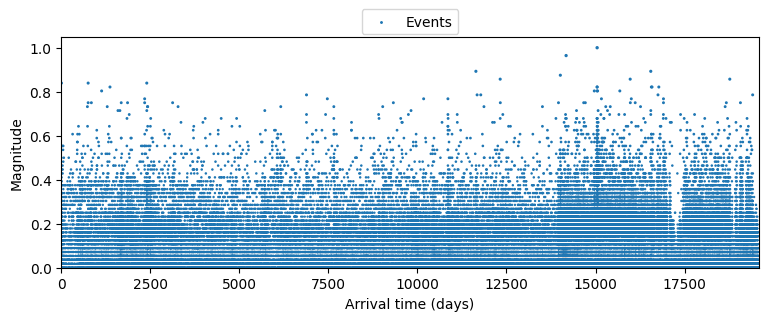

In [ ]:
import src.catalogs.visualization as viz
viz.visualize_sequence(CD_catalog.full_sequence)

In [ ]:
cd_sliding = chuandian.ChuanDianSlidingWindow(
    root_dir="/root/autodl-tmp/chuandian_eq/data/ChuanDian/raw",  # 用于存放生成的数据的目录
    catalog_file="/root/autodl-tmp/chuandian_eq/data/ChuanDian/raw/Chuandian2021.dat",  # 原始地震目录数据
    mag_completeness=3,              # 最小震级阈值
    window_size_days=200,              # 滑动窗口大小（单位：天）
    step_size_days=10,                 # 滑动步长（单位：天）
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15
)


Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/ChuanDian/raw.
Generated 1939 sliding window sequences.


In [ ]:
cd_sliding.train[0].keys()
cd_sliding.train[0].t_start
cd_sliding.train[0].t_nll_start

0.0

In [ ]:
dl= cd_sliding.test.get_dataloader(batch_size=32,shuffle=False)
for batch in dl:
    # print(batch['arrival_times'])
    print(batch[:,1:].inter_times[0])
    print(batch[:,1:].arrival_times[0])

tensor([1.1427e+00, 1.5724e-01, 4.5784e-01, 1.0924e-01, 5.3220e-01, 1.7414e+00,
        1.1846e-01, 6.6444e-01, 5.7248e-02, 4.7090e+00, 3.5533e+00, 2.2361e+00,
        2.5500e+00, 7.0284e-01, 4.7281e+00, 2.0967e-01, 7.6913e-01, 1.2578e-01,
        2.5674e-01, 1.7913e+00, 2.5270e+00, 2.5437e+00, 5.3116e-01, 2.3072e+00,
        1.2774e+00, 2.7360e-01, 3.5095e-01, 3.6503e-01, 1.8587e+00, 2.6735e+00,
        3.2333e-02, 5.1007e+00, 8.2487e-01, 1.8500e-01, 6.4938e-01, 1.7499e+00,
        4.2135e-01, 2.8482e+00, 5.3877e-01, 3.9195e+00, 5.5753e+00, 3.2560e+00,
        6.3624e-01, 1.0244e+00, 9.1871e-02, 5.6219e-01, 1.4072e+00, 7.7626e-01,
        8.8010e-01, 2.8778e-02, 3.8865e+00, 1.8309e+00, 2.1264e-01, 5.7479e+00,
        1.0174e+00, 8.6669e-03, 1.0761e-01, 9.4188e-03, 4.3028e-02, 4.7143e-01,
        5.1893e+00, 5.2819e+00, 1.3031e+00, 2.4728e-01, 8.0754e-01, 1.3843e+00,
        1.5888e-01, 8.6210e-02, 6.8336e-02, 1.2613e+00, 1.5252e+00, 7.6634e-02,
        2.1148e-01, 7.2705e-01, 1.2499e-

In [ ]:
batch.keys()

['inter_times',
 'arrival_times',
 't_start',
 't_end',
 't_nll_start',
 'nll_mask',
 'start_idx',
 'end_idx',
 'non_pad_mask',
 'type_seq',
 'mag',
 'loc',
 'depth']

In [ ]:
torch.max(batch['inter_times'])

tensor(200.)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from src.models.SubLayers import ScaledSoftplus
from src.models.Layers import MLP, CNN, AttentionPooling
from src.models.dstpp.Models import Transformer, Transformer_ST, Transformer_STM, Transformer_SE


class THP(nn.Module):
    def __init__(self, args, device):
        super().__init__()
        self.device = device
        self.use_mc_samples = getattr(args, 'use_mc_samples', True)  # Use Monte Carlo samples for non-event LL
        self.pad_token_id = getattr(args, 'pad_token_id', -100)
        self.eps = torch.finfo(torch.float32).eps
        self.num_event_types = getattr(args, 'num_event_types', 1)
        self.loss_integral_num_sample_per_step = getattr(args, 'integral_num_sample', 100)  

        self.transformer = Transformer_ST(
            d_model=args.d_model,
            d_rnn=args.d_rnn,
            d_inner=args.d_inner,
            n_layers=args.n_layers,
            n_head=args.n_head,
            d_k=args.d_k,
            d_v=args.d_v,
            dropout=args.t_dropout,
            dropout_post_rnn = getattr(args, 'rnn_dropout', 0), 
            device=device,
            loc_dim=args.dim,
            CosSin=True,
            attn_type=args.attn_type,
        ).to(self.device)
        
       
        self.factor_intensity_base = nn.Parameter(torch.empty([1, self.num_event_types], device=self.device))
        self.factor_intensity_decay = nn.Parameter(torch.empty([1, self.num_event_types], device=self.device))
        nn.init.xavier_normal_(self.factor_intensity_base)
        nn.init.xavier_normal_(self.factor_intensity_decay)

        self.layer_intensity_hidden = nn.Linear(3*args.d_model, getattr(args, 'num_event_types', 1), bias=True)
        self.softplus = ScaledSoftplus(self.num_event_types)   # learnable mark-spe
    

    def forward(self, x):
        f_seq, t_n_seq = self._batch_to_model_input(x)
        enc_out, seq_mask  = self.transformer(f_seq[:,:-1,:], t_n_seq[:,:-1])
        return enc_out, seq_mask .squeeze(-1)
    
    def _build_type_seq(self, seq_mask):
        type_seq = torch.full_like(seq_mask, fill_value=self.pad_token_id, dtype=torch.long)
        type_seq[seq_mask.bool()] = 0
        return type_seq
    
    def log_likelihood(self, x):
        time_delta_seqs = x.inter_times
        enc_out, seq_mask = self.forward(x)
        type_seq = self._build_type_seq(seq_mask)

        factor_intensity_decay = self.factor_intensity_decay[None, ...]
        factor_intensity_base = self.factor_intensity_base[None, ...]
        intensity_states = factor_intensity_decay * time_delta_seqs[:, 1:, None] + self.layer_intensity_hidden(
            enc_out) + factor_intensity_base
        lambda_at_event = self.softplus(intensity_states)
        sample_dtimes = self.make_dtime_loss_samples(time_delta_seqs[:, 1:])

        state_t_sample = self.compute_states_at_sample_times(event_states=enc_out,
                                                             sample_dtimes=sample_dtimes)
        lambda_t_sample = self.softplus(state_t_sample)
        event_ll, non_event_ll, num_events = self.compute_loglikelihood(lambda_at_event=lambda_at_event,
                                                                        lambdas_loss_samples=lambda_t_sample,
                                                                        time_delta_seq=time_delta_seqs[:, 1:],
                                                                        seq_mask=seq_mask.long(),
                                                                        type_seq=type_seq.long())

        loss = - (event_ll - non_event_ll).sum()
        return loss, num_events

    def make_dtime_loss_samples(self, time_delta_seq):
        """Generate the time point samples for every interval.

        Args:
            time_delta_seq (tensor): [batch_size, seq_len].

        Returns:
            tensor: [batch_size, seq_len, n_samples]
        """
        # [1, 1, n_samples]
        dtimes_ratio_sampled = torch.linspace(start=0.0,
                                              end=1.0,
                                              steps=self.loss_integral_num_sample_per_step,
                                              device=self.device)[None, None, :]

        # [batch_size, max_len, n_samples]
        sampled_dtimes = time_delta_seq[:, :, None] * dtimes_ratio_sampled

        return sampled_dtimes
    


    def compute_states_at_sample_times(self, event_states, sample_dtimes):
        """Compute the hidden states at sampled times.

        Args:
            event_states (tensor): [batch_size, seq_len, hidden_size].
            sample_dtimes (tensor): [batch_size, seq_len, num_samples].

        Returns:
            tensor: hidden state at each sampled time.
        """
        # [batch_size, seq_len, 1, hidden_size]
        event_states = event_states[:, :, None, :]

        # [batch_size, seq_len, num_samples, 1]
        sample_dtimes = sample_dtimes[..., None]

        # [1, 1, 1, num_event_types]
        factor_intensity_decay = self.factor_intensity_decay[None, None, ...]
        factor_intensity_base = self.factor_intensity_base[None, None, ...]

        # update time decay based on Equation (6)
        # [batch_size, seq_len, num_samples, num_event_types]
        intensity_states = factor_intensity_decay * sample_dtimes + self.layer_intensity_hidden(
            event_states) + factor_intensity_base

        return intensity_states
    
    def compute_loglikelihood(self, time_delta_seq, lambda_at_event, lambdas_loss_samples, seq_mask, type_seq):
        """Compute the loglikelihood of the event sequence based on Equation (8) of NHP paper.

        Args:
            time_delta_seq (tensor): [batch_size, seq_len], time_delta_seq from model input.
            lambda_at_event (tensor): [batch_size, seq_len, num_event_types], unmasked intensity at
            (right after) the event.
            lambdas_loss_samples (tensor): [batch_size, seq_len, num_sample, num_event_types],
            intensity at sampling times.
            seq_mask (tensor): [batch_size, seq_len], sequence mask vector to mask the padded events.
            type_seq (tensor): [batch_size, seq_len], sequence of mark ids, with padded events having a mark of self.pad_token_id

        Returns:
            tuple: event loglike, non-event loglike, intensity at event with padding events masked
        """  
        # First, add an epsilon to every marked intensity for stability
        lambda_at_event = lambda_at_event + self.eps
        lambdas_loss_samples = lambdas_loss_samples + self.eps

        log_marked_event_lambdas = lambda_at_event.log()
        total_sampled_lambdas = lambdas_loss_samples.sum(dim=-1)

        # Compute event LL - [batch_size, seq_len]
        event_ll = -F.nll_loss(
            log_marked_event_lambdas.permute(0, 2, 1),  # mark dimension needs to come second, not third to match nll_loss specs
            target=type_seq,
            ignore_index=self.pad_token_id,  # Padded events have a pad_token_id as a value
            reduction='none', # Does not aggregate, and replaces what would have been the log(marked intensity) with 0.
        )

        # Compute non-event LL [batch_size, seq_len]
        # interval_integral = length_interval * average of sampled lambda(t)
        if self.use_mc_samples:
            non_event_ll = total_sampled_lambdas.mean(dim=-1) * time_delta_seq * seq_mask
        else: # Use trapezoid rule
            non_event_ll = 0.5 * (total_sampled_lambdas[..., 1:] + total_sampled_lambdas[..., :-1]).mean(dim=-1) * time_delta_seq * seq_mask

        num_events = torch.masked_select(event_ll, event_ll.ne(0.0)).size()[0]
        return event_ll, non_event_ll, num_events
    
    @staticmethod
    def _batch_to_model_input(bx):
        t_seq = bx.arrival_times
        t_delta_seqs = bx.inter_times
        mag_seq = bx.mag
        loc_seq = bx.loc
        dep_seq = bx.depth
        f_seq = torch.concat((loc_seq, mag_seq.unsqueeze(2)), dim=-1)
        return f_seq, t_seq

2025-06-13 14:01:51.454072: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-13 14:01:51.467133: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749794511.481938   15168 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749794511.486312   15168 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749794511.498232   15168 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
import src.models.TppModels as tpp_models
import importlib
importlib.reload(tpp_models)

<module 'src.models.TppModels' from '/root/autodl-tmp/chuandian_eq/src/models/TppModels.py'>

In [ ]:
from config.config_loader import load_args_from_yaml
args = load_args_from_yaml('config/Classifier.yaml')
args.attn_type = 'full'

In [ ]:
thp_model = tpp_models.THP(args, device='cuda').to('cuda')

In [ ]:
thp_model(batch.to('cuda')).shape

torch.Size([13, 770, 384])

In [ ]:
thp_model.log_likelihood(batch.to('cuda'))

lambda_at_event stats: 1.372234582901001 1.558428406715393


(tensor(540.1381, device='cuda:0', grad_fn=<NegBackward0>), 9604)

In [ ]:
optimizer = torch.optim.AdamW(thp_model.parameters(), lr=1e-3, weight_decay=1e-4)
for epoch in range(10):
    thp_model.train()
    for batch in dl_train:
        batch.to('cuda')
        optimizer.zero_grad()
        loss, num_events = thp_model.log_likelihood(batch)
        loss.backward()
        optimizer.step()
        print(f'Epoch {epoch}, Loss: {loss.item()}')

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.25 GiB. GPU 0 has a total capacity of 23.53 GiB of which 6.51 GiB is free. Including non-PyTorch memory, this process has 17.01 GiB memory in use. Of the allocated memory 16.46 GiB is allocated by PyTorch, and 99.71 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)